**Import Libraries**



In [1]:
import os
import shutil
import random
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Set Dataset Paths**

In [3]:
!rm -rf /content/PlantVillage-Dataset
!git clone https://github.com/gabrieldgf4/PlantVillage-Dataset.git /content/PlantVillage-Dataset

Cloning into '/content/PlantVillage-Dataset'...
remote: Enumerating objects: 54511, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 54511 (delta 36), reused 0 (delta 0), pack-reused 54403 (from 1)
Receiving objects: 100% (54511/54511), 806.27 MiB | 34.88 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Updating files: 100% (54306/54306), done.


**Prepare Binary Dataset**

In [4]:
from pathlib import Path
base = Path("/content/PlantVillage-Dataset")

print("Base exists:", base.exists())
print("\nTop-level folders/files:")
for p in base.iterdir():
    print(p.name)

Base exists: True

Top-level folders/files:
.git
Corn_(maize)___Common_rust_
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Strawberry___Leaf_scorch
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Orange___Haunglongbing_(Citrus_greening)
x_Removed_from_Healthy_leaves
Tomato___Target_Spot
Grape___healthy
Tomato___Leaf_Mold
Cherry_(including_sour)___healthy
Tomato___Tomato_mosaic_virus
Squash___Powdery_mildew
Strawberry___healthy
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Corn_(maize)___healthy
Tomato___Bacterial_spot
Soybean___healthy
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Septoria_leaf_spot
Tomato___Early_blight
Grape___Esca_(Black_Measles)
Peach___healthy
Apple___Apple_scab
Apple___Black_rot
README.md
Grape___Black_rot
Potato___healthy
Blueberry___healthy
Apple___healthy
Potato___Late_blight
Pepper,_bell___Bacterial_spot
Peach___Bacterial_spot
Tomato___healthy
Pepper,_bell___healthy
Raspberry___healthy
Corn_(maize)___Northern_Leaf_Blight
Tomato___Late_blight
Potato___Early_

**Load Image Datasets**

In [5]:
from pathlib import Path
import shutil
import random

source_root = Path("/content/PlantVillage-Dataset")

binary_root = Path("/content/binary_plant_dataset")
healthy_dir = binary_root / "healthy"
diseased_dir = binary_root / "diseased"

if binary_root.exists():
    shutil.rmtree(binary_root)

healthy_dir.mkdir(parents=True, exist_ok=True)
diseased_dir.mkdir(parents=True, exist_ok=True)

print("Binary folders ready")

Binary folders ready


**Optimize Data Pipeline**

In [6]:
valid_exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

healthy_count = 0
diseased_count = 0

for class_folder in source_root.iterdir():
    if not class_folder.is_dir():
        continue

    class_name = class_folder.name.lower()

    if "removed_from_healthy" in class_name:
        continue

    target_dir = healthy_dir if "healthy" in class_name else diseased_dir

    for img_path in class_folder.iterdir():
        if img_path.suffix in valid_exts:
            new_name = f"{class_folder.name}___{img_path.name}"
            shutil.copy2(img_path, target_dir / new_name)

            if target_dir == healthy_dir:
                healthy_count += 1
            else:
                diseased_count += 1

print("Healthy images:", healthy_count)
print("Diseased images:", diseased_count)

Healthy images: 15079
Diseased images: 39221


**Compute Class Weights**

In [7]:
split_root = Path("/content/split_plant_dataset")

if split_root.exists():
    shutil.rmtree(split_root)

for split in ["train", "val", "test"]:
    for cls in ["healthy", "diseased"]:
        (split_root / split / cls).mkdir(parents=True, exist_ok=True)

print("Split folders created")

Split folders created


In [8]:
def split_and_copy(src_dir, class_name, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    files = list(src_dir.glob("*"))
    random.shuffle(files)

    total = len(files)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    for f in train_files:
        shutil.copy2(f, split_root / "train" / class_name / f.name)

    for f in val_files:
        shutil.copy2(f, split_root / "val" / class_name / f.name)

    for f in test_files:
        shutil.copy2(f, split_root / "test" / class_name / f.name)

split_and_copy(healthy_dir, "healthy")
split_and_copy(diseased_dir, "diseased")

for split in ["train", "val", "test"]:
    for cls in ["healthy", "diseased"]:
        count = len(list((split_root / split / cls).glob("*")))
        print(split, cls, count)

train healthy 10555
train diseased 27454
val healthy 2261
val diseased 5883
test healthy 2263
test diseased 5884


In [9]:
img_height = 160
img_width = 160
batch_size = 16
import tensorflow as tf
train_ds = tf.keras.utils.image_dataset_from_directory(
    split_root / "train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    split_root / "val",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    split_root / "test",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 38009 files belonging to 2 classes.
Found 8144 files belonging to 2 classes.
Found 8147 files belonging to 2 classes.


In [10]:
total = healthy_count + diseased_count
weight_for_0 = total / (2 * healthy_count)   # class 0: healthy
weight_for_1 = total / (2 * diseased_count)  # class 1: diseased

class_weight = {0: weight_for_0, 1: weight_for_1}
class_weight

{0: 1.8005172756814112, 1: 0.692231202672038}

**Load Pretrained MobileNetV2 Base Model**

In [11]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weight
)

Epoch 1/5
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 111s 33ms/step - accuracy: 0.8661 - loss: 0.2732 - val_accuracy: 0.9423 - val_loss: 0.1556
Epoch 2/5
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 89s 30ms/step - accuracy: 0.9350 - loss: 0.1465 - val_accuracy: 0.9544 - val_loss: 0.1234
Epoch 3/5
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9487 - loss: 0.1206 - val_accuracy: 0.9579 - val_loss: 0.1101
Epoch 4/5
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 143s 29ms/step - accuracy: 0.9538 - loss: 0.1089 - val_accuracy: 0.9606 - val_loss: 0.1022
Epoch 5/5
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 139s 28ms/step - accuracy: 0.9567 - loss: 0.1031 - val_accuracy: 0.9649 - val_loss: 0.0937


In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

model.save("/content/plant_binary_model.keras")

510/510 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9642 - loss: 0.0942
Test Accuracy: 0.9641585946083069


In [14]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [15]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=class_weight
)

test_loss_fine, test_acc_fine = model.evaluate(test_ds)
print("Fine-tuned Test Accuracy:", test_acc_fine)

model.save("/content/plant_binary_model_finetuned.keras")

Epoch 1/3
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 130s 42ms/step - accuracy: 0.9520 - loss: 0.1151 - val_accuracy: 0.9641 - val_loss: 0.0935
Epoch 2/3
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 113s 40ms/step - accuracy: 0.9694 - loss: 0.0759 - val_accuracy: 0.9881 - val_loss: 0.0380
Epoch 3/3
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 143s 42ms/step - accuracy: 0.9782 - loss: 0.0583 - val_accuracy: 0.9901 - val_loss: 0.0279
510/510 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9899 - loss: 0.0282
Fine-tuned Test Accuracy: 0.9899349212646484


In [16]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

model.save("/content/drive/MyDrive/plant_binary_model_finetuned.keras")
print("Model saved to Drive successfully")

Mounted at /content/drive
Model saved to Drive successfully


In [17]:
test_loss_fine, test_acc_fine = model.evaluate(test_ds)
print("Fine-tuned Test Accuracy:", test_acc_fine)
print("Fine-tuned Test Loss:", test_loss_fine)

510/510 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9899 - loss: 0.0282
Fine-tuned Test Accuracy: 0.9899349212646484
Fine-tuned Test Loss: 0.028168417513370514


**Confusion Matrix and Classification Report**

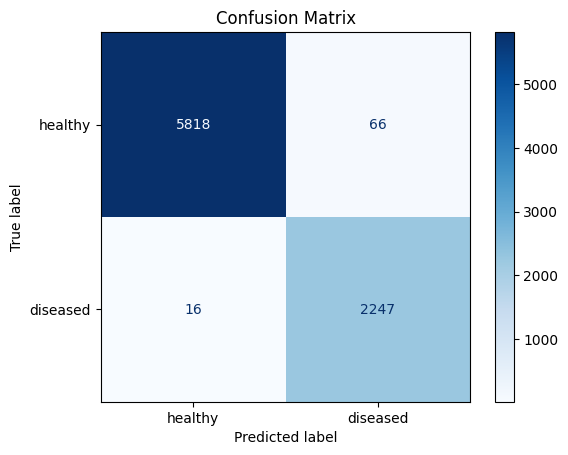

              precision    recall  f1-score   support

     healthy       1.00      0.99      0.99      5884
    diseased       0.97      0.99      0.98      2263

    accuracy                           0.99      8147
   macro avg       0.98      0.99      0.99      8147
weighted avg       0.99      0.99      0.99      8147



In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = (probs >= 0.5).astype("int32").flatten()
    y_true.extend(labels.numpy().astype("int32"))
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["healthy", "diseased"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=["healthy", "diseased"]))

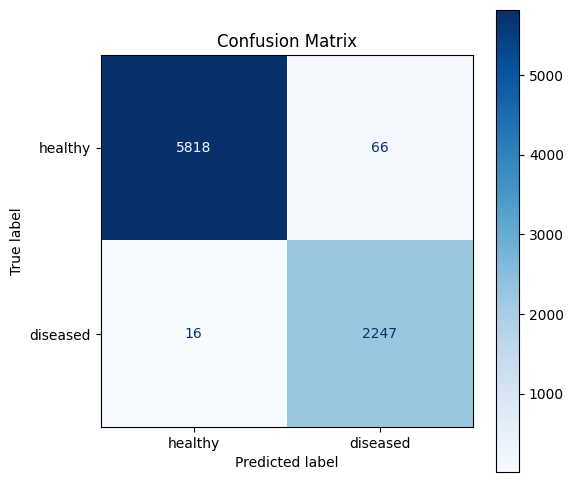

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["healthy", "diseased"])
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix")
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", bbox_inches="tight")
plt.show()

In [20]:
model = tf.keras.models.load_model("/content/drive/MyDrive/plant_binary_model_finetuned.keras")

In [21]:
from pathlib import Path

healthy_dir = Path("/content/split_plant_dataset/test/healthy")
diseased_dir = Path("/content/split_plant_dataset/test/diseased")

healthy_img_path = list(healthy_dir.glob("*"))[0]
diseased_img_path = list(diseased_dir.glob("*"))[0]

print("Healthy sample:", healthy_img_path)
print("Diseased sample:", diseased_img_path)

Healthy sample: /content/split_plant_dataset/test/healthy/Cherry_(including_sour)___healthy___feee45d9-e66f-499f-8ca9-e76881aa10ab___JR_HL 9756.JPG
Diseased sample: /content/split_plant_dataset/test/diseased/Tomato___Septoria_leaf_spot___07a4190c-b0c0-4e03-9ad5-474938c837d2___Matt.S_CG 1242.JPG


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

IMG_SIZE = (160, 160)

def predict_single_image(img_path, model):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    prob = model.predict(img_array, verbose=0)[0][0]
    label = "Diseased" if prob >= 0.5 else "Healthy"
    confidence = prob if prob >= 0.5 else 1 - prob

    plt.imshow(tf.keras.utils.load_img(img_path))
    plt.title(f"Prediction: {label} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

    print("File:", img_path)
    print("Predicted label:", label)
    print(f"Confidence: {confidence*100:.2f}%")
    print(f"Raw sigmoid output: {prob:.4f}")

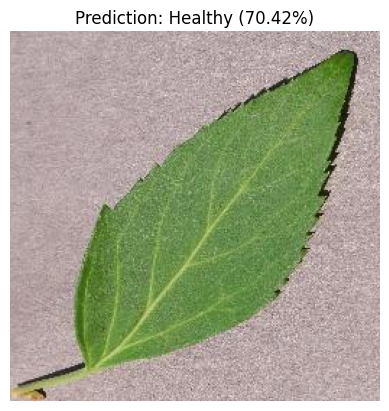

File: /content/split_plant_dataset/test/healthy/Cherry_(including_sour)___healthy___feee45d9-e66f-499f-8ca9-e76881aa10ab___JR_HL 9756.JPG
Predicted label: Healthy
Confidence: 70.42%
Raw sigmoid output: 0.2958


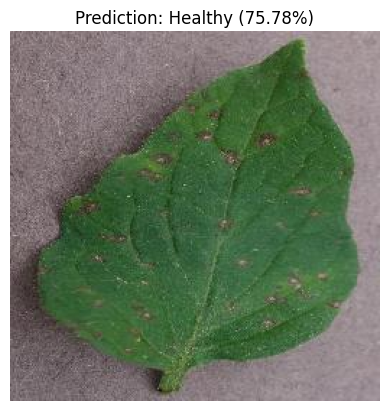

File: /content/split_plant_dataset/test/diseased/Tomato___Septoria_leaf_spot___07a4190c-b0c0-4e03-9ad5-474938c837d2___Matt.S_CG 1242.JPG
Predicted label: Healthy
Confidence: 75.78%
Raw sigmoid output: 0.2422


In [23]:
predict_single_image(healthy_img_path, model)
predict_single_image(diseased_img_path, model)

In [24]:
from google.colab import files

uploaded = files.upload()

Saving leaf3.jpg to leaf3.jpg


**Single Leaf Image Prediction Demo**

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

IMG_SIZE = (160, 160)

def predict_uploaded_image(img_path, model):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    prob = model.predict(img_array, verbose=0)[0][0]
    label = "Diseased" if prob >= 0.5 else "Healthy"
    confidence = prob if prob >= 0.5 else 1 - prob

    plt.imshow(tf.keras.utils.load_img(img_path))
    plt.title(f"Prediction: {label} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

    print("Predicted label:", label)
    print(f"Confidence: {confidence*100:.2f}%")
    print(f"Raw output: {prob:.4f}")

In [26]:
print(uploaded.keys())

dict_keys(['leaf3.jpg'])


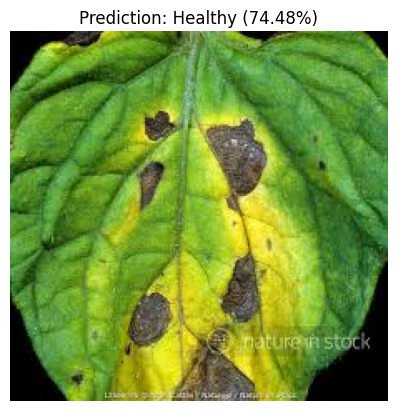

Predicted label: Healthy
Confidence: 74.48%
Raw output: 0.2552


In [27]:
predict_uploaded_image("/content/leaf3.jpg", model)

In [28]:
import os

print(os.path.exists("/content/drive/MyDrive/plant_binary_model_finetuned.keras"))

True


In [29]:
import os

for f in os.listdir("/content/drive/MyDrive"):
    if f.endswith(".keras"):
        print(f)

plant_binary_model_finetuned.keras


In [30]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_binary_model_finetuned.keras"
)
print("Loaded model summary:")
loaded_model.summary()

Loaded model summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314,629 (20.27 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,055,364 (11.66 MB)

In [31]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_binary_model_finetuned.keras"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


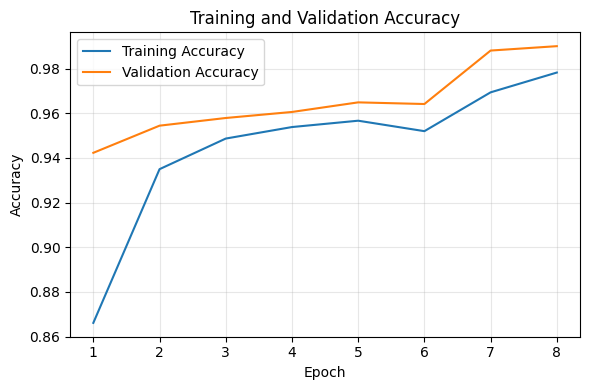

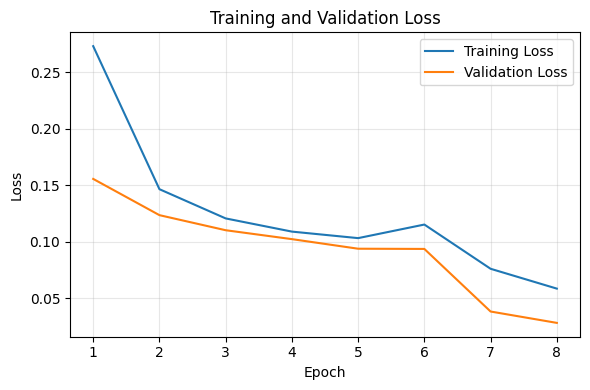

Saved: fig_accuracy.png and fig_loss.png in MyDrive


In [32]:
import matplotlib.pyplot as plt

# Combine history from feature-extraction phase and fine-tuning phase
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

# ----- Figure 5.1: Accuracy vs Epochs -----
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fig_accuracy.png", dpi=300)
plt.show()

# ----- Figure 5.2: Loss vs Epochs -----
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fig_loss.png", dpi=300)
plt.show()

print("Saved: fig_accuracy.png and fig_loss.png in MyDrive")

In [33]:
import os
from pathlib import Path

def count_images(root):
    root = Path(root)
    counts = {}
    for split in ["train", "val", "test"]:
        split_path = root / split
        split_counts = {}
        for cls in ["healthy", "diseased"]:
            cls_path = split_path / cls
            n = len(list(cls_path.glob("*")))
            split_counts[cls] = n
        counts[split] = split_counts
    return counts

dataset_counts = count_images("/content/split_plant_dataset")
dataset_counts

{'train': {'healthy': 10555, 'diseased': 27454},
 'val': {'healthy': 2261, 'diseased': 5883},
 'test': {'healthy': 2263, 'diseased': 5884}}

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["healthy", "diseased"]))

              precision    recall  f1-score   support

     healthy       1.00      0.99      0.99      5884
    diseased       0.97      0.99      0.98      2263

    accuracy                           0.99      8147
   macro avg       0.98      0.99      0.99      8147
weighted avg       0.99      0.99      0.99      8147



In [35]:
!git config --global user.email "swati.30.kumari.05@gmail.com"
!git config --global user.name "swati30kumari05"

In [36]:
!git clone https://github.com/swati30kumari05/plant-disease-detection.git
%cd plant-disease-detection

Cloning into 'plant-disease-detection'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
Resolving deltas: 100% (1/1), done.
/content/plant-disease-detection
